#### SSA LPG Facility Allocation
##### **Nigeria-trained logistic regression models → Sub-Saharan Africa facility placement**

This notebook:
1. Loads Nigeria-trained logistic regression models + allocation parameters
2. Iterates over every SSA country defined in the configuration dictionary
3. Aligns rasters, computes LPG user estimates, sets facility targets
4. Generates probability rasters (with optional predictor weighting)
5. Runs an anti-clustering iterative allocation to place new facilities
6. Writes per-country `.gpkg` files and a merged Africa-wide output

---


#### 0 · Imports

In [10]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import rowcol, xy
from rasterio.features import geometry_mask
from scipy.spatial import cKDTree
from shapely.geometry import Point, mapping
import fiona
import matplotlib.pyplot as plt



warnings.filterwarnings("ignore")

from scipy.ndimage import convolve
def compute_neighborhood_sum(raster_array, radius_km, pixel_size_m):
    """Calculates the total sum of a variable within a circular radius (e.g., total population around a cell)."""
    radius_pixels = int(round((radius_km * 1000) / pixel_size_m))
    y, x = np.ogrid[-radius_pixels:radius_pixels+1, -radius_pixels:radius_pixels+1]
    kernel = (x**2 + y**2 <= radius_pixels**2).astype(float)
    
    # Temporarily replace NaNs with 0 to prevent NaN propagation during convolution
    mask_nan = np.isnan(raster_array)
    clean_array = np.where(mask_nan, 0.0, raster_array)
    
    smoothed = convolve(clean_array, kernel, mode='constant', cval=0.0)
    smoothed[mask_nan] = np.nan
    return smoothed

def compute_neighborhood_mean(raster_array, radius_km, pixel_size_m):
    """Calculates the true average of a variable within a circular radius, ignoring NaNs."""
    radius_pixels = int(round((radius_km * 1000) / pixel_size_m))
    y, x = np.ogrid[-radius_pixels:radius_pixels+1, -radius_pixels:radius_pixels+1]
    kernel = (x**2 + y**2 <= radius_pixels**2).astype(float)
    
    mask_valid = (~np.isnan(raster_array)).astype(float)
    clean_array = np.where(np.isnan(raster_array), 0.0, raster_array)
    
    # Calculate the sum of values and count of valid pixels within the window
    sum_spatial = convolve(clean_array, kernel, mode='constant', cval=0.0)
    count_spatial = convolve(mask_valid, kernel, mode='constant', cval=0.0)
    
    # Avoid zero division
    with np.errstate(divide='ignore', invalid='ignore'):
        mean_spatial = np.where(count_spatial > 0, sum_spatial / count_spatial, np.nan)
    
    mean_spatial[np.isnan(raster_array)] = np.nan
    return mean_spatial

#### 1 · Global Configuration

Edit this section to adjust paths, flags, and predictor weights.

> **Predictor weights** (0–1): these are USER overrides on top of the
> Nigeria-trained logistic model coefficients. A weight of 1 means "use the
> predictor exactly as the model learned it". A weight of 0 forces the
> predictor's log-odds contribution to zero (equivalent to removing it).
> The relative importance between predictors is still governed by the model
> coefficients — e.g. if income has a larger coefficient than friction in the
> Nigeria model, it will contribute more to the probability even when both
> weights are 1. Set a weight < 1 only if you have a reason to distrust that
> predictor for the target context.
>
> If a raster is missing for a country, the weight for that predictor is
> automatically forced to 0 for that country.


In [11]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_ROOT    = "SSA"                         # root folder: data/<country_name>/
MODELS_DIR   = "SSA/models"                       # Nigeria-trained models
INFRA_GPKG   = os.path.join(DATA_ROOT, "infrastructure.gpkg")
COUNTRIES_SHP= os.path.join(DATA_ROOT, "location_total/world_bound/ne_110m_admin_0_countries.shp")
OUTPUT_DIR   = "SSA/country_separate"             # intermediate per-country outputs
FINAL_GPKG   = "SSA/ssa_lpg_facilities_all.gpkg" # merged Africa-wide output
SHARED_INPUT_DIR = os.path.join(DATA_ROOT, "all_inputSSA")

# ── Urban raster threshold (same for every country) ──────────────────────────
URBAN_THRESHOLD = 20      # pixel value >= this → urban

# ── Reference CRS (must match Nigeria training CRS) ──────────────────────────
TARGET_CRS = "EPSG:3857"

# ── Behaviour flags ───────────────────────────────────────────────────────────
USE_EXISTING_INFRASTRUCTURE = True
# True  → existing facilities REDUCE the number of new ones needed
# False → existing facilities only affect anti-clustering; target count fixed

# ── Predictor weights (0.0 – 1.0) ────────────────────────────────────────────
# Set to 0 to exclude a predictor; 1 to use it at full (model-learned) strength.
# Weights of 1 everywhere = pure Nigeria model output (recommended default).
PREDICTOR_WEIGHTS = {
    "income":     1.0,
    "population": 1.0,
    "is_urban":   1.0,
    "friction":   1.0,
}
# ── Anti‑clustering penalty per facility type (percentage) ─────────────────────
#   penalty = 0  → no dampening (free allocation)
#   penalty = 100 → neighbour probability set to 0 (complete prohibition)
RESELLER_PENALTY_PCT = 19
FILLING_PENALTY_PCT   = 48.5

# ── Visual jitter for combined resell+filling layer (metres in EPSG:3857) ─────
OVERLAP_JITTER_M = 10   # each type offset by ±OVERLAP_JITTER_M/2

print("Configuration loaded.")
print(f"  USE_EXISTING_INFRASTRUCTURE : {USE_EXISTING_INFRASTRUCTURE}")
print(f"  PREDICTOR_WEIGHTS           : {PREDICTOR_WEIGHTS}")
print(f"  RESELLER_PENALTY_PCT        : {RESELLER_PENALTY_PCT}%")
print(f"  FILLING_PENALTY_PCT         : {FILLING_PENALTY_PCT}%")

Configuration loaded.
  USE_EXISTING_INFRASTRUCTURE : True
  PREDICTOR_WEIGHTS           : {'income': 1.0, 'population': 1.0, 'is_urban': 1.0, 'friction': 1.0}
  RESELLER_PENALTY_PCT        : 19%
  FILLING_PENALTY_PCT         : 48.5%


#### 2 · Country Dictionary

Required keys per entry:
- `urban_lpg_share` – fraction of urban population using LPG
- `rural_lpg_share` – fraction of rural population using LPG

Optional per-country overrides (fall back to Nigeria values if absent):
- `reseller_urban`, `reseller_rural` – resellers per 1 000 LPG users
- `filling_urban`,  `filling_rural`  – filling stations per 1 000 LPG users


In [12]:
SSA_COUNTRIES = {
    'angola': {'urban_lpg_share': 0.6897, 'rural_lpg_share': 0.0791},
    'burundi': {'urban_lpg_share': 0.0000, 'rural_lpg_share': 0.0001},
    'benin': {'urban_lpg_share': 0.0639, 'rural_lpg_share': 0.0057},
    'burkina faso': {'urban_lpg_share': 0.3473, 'rural_lpg_share': 0.0100},
    'botswana': {'urban_lpg_share': 0.2426, 'rural_lpg_share': 0.1139},
    'central african republic': {'urban_lpg_share': 0.0018, 'rural_lpg_share': 0.0000},
    'ivory coast': {'urban_lpg_share': 0.6099, 'rural_lpg_share': 0.0169},
    'cameroon': {'urban_lpg_share': 0.4160, 'rural_lpg_share': 0.0184},
    'democratic republic of the congo': {'urban_lpg_share': 0.0008, 'rural_lpg_share': 0.0000},
    'republic of the congo': {'urban_lpg_share': 0.5047, 'rural_lpg_share': 0.0266},
    'djibouti': {'urban_lpg_share': 0.0703, 'rural_lpg_share': 0.0024},
    'eritrea': {'urban_lpg_share': 0.1889, 'rural_lpg_share': 0.0029},
    'ethiopia': {'urban_lpg_share': 0.0064, 'rural_lpg_share': 0.0008},
    'gabon': {'urban_lpg_share': 0.9270, 'rural_lpg_share': 0.4314},
    'ghana': {'urban_lpg_share': 0.4448, 'rural_lpg_share': 0.1109},
    'guinea': {'urban_lpg_share': 0.0031, 'rural_lpg_share': 0.0008},
    'gambia': {'urban_lpg_share': 0.0144, 'rural_lpg_share': 0.0003},
    'guinea-bissau': {'urban_lpg_share': 0.0179, 'rural_lpg_share': 0.0002},
    'equatorial guinea': {'urban_lpg_share': 0.2917, 'rural_lpg_share': 0.0308},
    'kenya': {'urban_lpg_share': 0.2218, 'rural_lpg_share': 0.0230},
    'liberia': {'urban_lpg_share': 0.0003, 'rural_lpg_share': 0.0001},
    'lesotho': {'urban_lpg_share': 0.3844, 'rural_lpg_share': 0.1341},
    'madagascar': {'urban_lpg_share': 0.0061, 'rural_lpg_share': 0.0002},
    'mali': {'urban_lpg_share': 0.0093, 'rural_lpg_share': 0.0014},
    'mozambique': {'urban_lpg_share': 0.0834, 'rural_lpg_share': 0.0022},
    'mauritania': {'urban_lpg_share': 0.6087, 'rural_lpg_share': 0.1787},
    'malawi': {'urban_lpg_share': 0.0015, 'rural_lpg_share': 0.0001},
    'namibia': {'urban_lpg_share': 0.1898, 'rural_lpg_share': 0.0328},
    'niger': {'urban_lpg_share': 0.1500, 'rural_lpg_share': 0.0004},
    'nigeria': {'urban_lpg_share': 0.25468, 'rural_lpg_share': 0.027905},
    'rwanda': {'urban_lpg_share': 0.0597, 'rural_lpg_share': 0.0026},
    'sudan': {'urban_lpg_share': 0.6598, 'rural_lpg_share': 0.4576},
    'senegal': {'urban_lpg_share': 0.3382, 'rural_lpg_share': 0.0265},
    'sierra leone': {'urban_lpg_share': 0.0035, 'rural_lpg_share': 0.0001},
    'somalia': {'urban_lpg_share': 0.0363, 'rural_lpg_share': 0.0007},
    'south sudan': {'urban_lpg_share': 0.0000, 'rural_lpg_share': 0.0001},
    'eswatini': {'urban_lpg_share': 0.1110, 'rural_lpg_share': 0.0408},
    'chad': {'urban_lpg_share': 0.1372, 'rural_lpg_share': 0.0000},
    'togo': {'urban_lpg_share': 0.2168, 'rural_lpg_share': 0.0025},
    'united republic of tanzania': {'urban_lpg_share': 0.0349, 'rural_lpg_share': 0.0016},
    'uganda': {'urban_lpg_share': 0.0006, 'rural_lpg_share': 0.0000},
    'south africa': {'urban_lpg_share': 0.0459, 'rural_lpg_share': 0.0290},
    'zambia': {'urban_lpg_share': 0.0011, 'rural_lpg_share': 0.0006},
    'zimbabwe': {'urban_lpg_share': 0.2278, 'rural_lpg_share': 0.0013},
}

print(f"Country dictionary: {len(SSA_COUNTRIES)} entries")

Country dictionary: 44 entries


#### 3 · Load Shared Resources

In [13]:
def load_models_and_params():
    """Load Nigeria-trained logistic models, scalers, and allocation params."""
    def _load(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return (
        _load(os.path.join(MODELS_DIR, 'logres_reseller.pkl')),
        _load(os.path.join(MODELS_DIR, 'logres_filling.pkl')),
        _load(os.path.join(MODELS_DIR, 'scaler_income.pkl')),
        _load(os.path.join(MODELS_DIR, 'scaler_population.pkl')),
        _load(os.path.join(MODELS_DIR, 'scaler_friction.pkl')),
        _load(os.path.join(MODELS_DIR, 'allocation_params.pkl')),
    )

print("Loading models …")
model_res, model_fill, scaler_income, scaler_pop, scaler_friction, NIG_PARAMS = (
    load_models_and_params()
)

# Load existing infrastructure (all SSA)
existing_resell  = gpd.read_file(INFRA_GPKG, layer='reseller_africa').to_crs(TARGET_CRS)
existing_filling = gpd.read_file(INFRA_GPKG, layer='filling_africa').to_crs(TARGET_CRS)

# Load country boundaries
world = gpd.read_file(COUNTRIES_SHP).to_crs(TARGET_CRS)

# Find the correct name column
possible_name_fields = ['ADMIN', 'NAME', 'SOVEREIGNT']
name_col = None
for col in possible_name_fields:
    if col in world.columns:
        name_col = col
        break

# Create lower-case name column
world['name_lower'] = world[name_col].str.lower()

# Filter to SSA countries only
ssa_names = set(SSA_COUNTRIES.keys())
countries_gdf = world[world['name_lower'].isin(ssa_names)].copy()

os.makedirs(OUTPUT_DIR, exist_ok=True)

fp = NIG_PARAMS['facilities_per_1000_lpg_users']
print(f"Models         : OK")
print(f"Existing infra : {len(existing_resell)} resellers | {len(existing_filling)} filling stations")
print(f"Countries      : {len(countries_gdf)} polygons")
print(f"Nigeria rates per 1 000 LPG users:")
print(f"  Reseller  urban={fp['reseller_urban']:.4f}  rural={fp['reseller_rural']:.4f}")
print(f"  Filling   urban={fp['filling_urban']:.4f}  rural={fp['filling_rural']:.4f}")

# Optional: verify country name matches
missing = [k for k in SSA_COUNTRIES if k not in countries_gdf['name_lower'].values]
if missing:
    print(f"\n⚠  Names NOT found in shapefile (check spelling): {missing}")
else:
    print("\n✔  All country names matched in shapefile.")

Loading models …
Models         : OK
Existing infra : 2538 resellers | 1239 filling stations
Countries      : 44 polygons
Nigeria rates per 1 000 LPG users:
  Reseller  urban=0.0930  rural=0.1326
  Filling   urban=0.0158  rural=0.0126

✔  All country names matched in shapefile.


#### 4 · Helper Functions

In [14]:
# ── Raster utilities ─────────────────────────────────────────────────────────

from rasterio.warp import transform


def align_raster(src_path, ref_shape, ref_transform, ref_crs):
    """Reproject a raster to the reference grid; nodata → NaN."""
    with rasterio.open(src_path) as src:
        out = np.full(ref_shape, np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear,
        )
        nd = src.nodata
        if nd is not None:
            out[out == nd] = np.nan
    return out


def points_to_rowcol(gdf, transform, shape):
    """Return valid (row, col) numpy arrays for points inside raster bounds."""
    xs = gdf.geometry.x.values
    ys = gdf.geometry.y.values
    rows, cols = rowcol(transform, xs, ys)
    rows, cols = np.asarray(rows), np.asarray(cols)
    valid = (rows >= 0) & (rows < shape[0]) & (cols >= 0) & (cols < shape[1])
    return rows[valid], cols[valid]


def clip_gdf_to_country(gdf, country_geom):
    """Clip a GeoDataFrame to a country polygon (intersection check)."""
    return gdf[gdf.intersects(country_geom)].copy()


def safe_name(country_name):
    """Convert country name to a filesystem-safe string."""
    return (country_name.lower()
            .replace(' ', '_').replace('.', '').replace("'", '')
            .replace('é', 'e').replace('ô', 'o').replace('ã', 'a')
            .replace('ç', 'c').replace('ó', 'o'))


# ── Probability raster ────────────────────────────────────────────────────────

def compute_probability_raster(
    pop, income, is_urban_bin, friction,
    scaler_pop, scaler_income, scaler_friction,
    model, predictor_weights, valid_mask,
):
    """
    Build a 2-D probability raster using the logistic model.

    Predictor weights scale the normalised predictor values:
      weight=1 → full model contribution (default)
      weight=0 → predictor zeroed (log-odds contribution removed)

    The logistic model's coefficients still encode the Nigeria-learned
    relative importance between predictors — weights are a top-level
    user override (e.g. to discount a predictor you distrust).

    Returns a float32 array shaped like `pop`, with NaN outside valid_mask.
    """
    w = predictor_weights

    flat_pop  = pop[valid_mask].reshape(-1, 1)
    flat_fric = friction[valid_mask].reshape(-1, 1) if friction is not None else None
    flat_inc  = income[valid_mask].reshape(-1, 1)   if income  is not None else None
    flat_urb  = is_urban_bin[valid_mask].astype(float).reshape(-1, 1)

    # Scale using Nigeria-trained scalers
    pop_sc  = scaler_pop.transform(flat_pop)  * w['population']
    fric_sc = (scaler_friction.transform(flat_fric) * w['friction']
               if flat_fric is not None else np.zeros_like(pop_sc))
    inc_sc  = (scaler_income.transform(flat_inc)    * w['income']
               if flat_inc  is not None else np.zeros_like(pop_sc))
    urb_sc  = flat_urb * w['is_urban']

    # Feature order must match training: income, population, is_urban, friction
    X = np.hstack([inc_sc, pop_sc, urb_sc, fric_sc])
    prob_flat = model.predict_proba(X)[:, 1]

    prob_2d = np.full(pop.shape, np.nan, dtype=np.float32)
    prob_2d[valid_mask] = prob_flat
    return prob_2d


# ── Anti-clustering & allocation ──────────────────────────────────────────────


def allocate_facilities(prob_2d, n_needed, existing_rows, existing_cols, transform, penalty_pct):
    """
    Greedy iterative allocation with anti-clustering.

    penalty_pct : percentage reduction of neighbour probabilities.
                  penalty=0 → no dampening; penalty=100 → neighbours set to 0.
    Algorithm:
      1. Mark all existing facility cells occupied.
      2. Pick the unoccupied cell with highest probability.
      3. Place a facility there; update probabilities of unoccupied neighbour cells by applying the penalty.
      4. Repeat until n_needed facilities placed.

    Returns list of (x, y) in TARGET_CRS.
    """
    if n_needed <= 0:
        return []

    prob = prob_2d.copy()
    rows, cols = prob.shape
    occupied = np.zeros(prob.shape, dtype=bool)

    # Mark existing facility cells occupied
    for r, c in zip(existing_rows, existing_cols):
        if 0 <= r < rows and 0 <= c < cols:
            occupied[r, c] = True

    factor = 1.0 - penalty_pct / 100.0   # penalty=18 → factor=0.82

    # Helper: apply factor to the 8-neighbourhood (radius=2)
    def apply_neighborhood_penalty(r, c):
        radius = 2
        r_min = max(0, r - radius)
        r_max = min(rows, r + radius + 1)
        c_min = max(0, c - radius)
        c_max = min(cols, c + radius + 1)
        prob[r_min:r_max, c_min:c_max] *= factor

    # Seed initial penalties around existing facilities
    for r, c in zip(existing_rows, existing_cols):
        if 0 <= r < rows and 0 <= c < cols:
            apply_neighborhood_penalty(r, c)

    placed_coords = []
    for _ in range(n_needed):
        valid = (~np.isnan(prob)) & (~occupied)
        if not np.any(valid):
            print(f"      ⚠ Only {len(placed_coords)}/{n_needed} placed (ran out of valid cells)")
            break

        prob_masked = np.where(valid, prob, -np.inf)
        max_idx = np.argmax(prob_masked)
        r, c = np.unravel_index(max_idx, prob.shape)

        x_m, y_m = xy(transform, r, c)
        placed_coords.append((x_m, y_m))

        occupied[r, c] = True
        prob[r, c] = 0.0
        apply_neighborhood_penalty(r, c)

    return placed_coords

def coords_to_gdf(coords_3857, country_name, fac_type, crs=TARGET_CRS):
    if not coords_3857: 
        return gpd.GeoDataFrame(
            columns=['country', 'type', 'source', 'geometry'], crs=crs)
            
    geoms = [Point(x, y) for x, y in coords_3857]
    
    return gpd.GeoDataFrame(
        {'country': country_name, 'type': fac_type, 'source': 'allocated'},
        geometry=geoms, 
        crs=crs,
        index=range(len(geoms)) 
    )


def add_jitter(gdf, dx_m, dy_m):
    """Translate all points by (dx_m, dy_m) metres (EPSG:3857)."""
    gdf = gdf.copy()
    gdf['geometry'] = gdf['geometry'].translate(xoff=dx_m, yoff=dy_m)
    return gdf


print("Helper functions defined.")

Helper functions defined.


#### 5 · Main Allocation Loop

Processes each country in `SSA_COUNTRIES`.


In [15]:
all_resell_new    = []   # new allocated resellers (all countries)
all_filling_new   = []   # new allocated filling stations
all_resell_exist  = []   # existing resellers clipped per country
all_filling_exist = []
predicted_val_resell = {}
predicted_val_filling = {}

print("COUNTRY ALLOCATION LOOP")


for country_name, c_cfg in SSA_COUNTRIES.items():

    # ── Find country boundary ─────────────────────────────────────────────────
    match = countries_gdf[countries_gdf['name_lower'] == country_name]
    if match.empty:
        print(f"\n[SKIP] {country_name}: not found in boundaries shapefile.")
        continue
    country_geom = match.geometry.unary_union

    # ── Build expected raster paths ───────────────────────────────────────────
    safe = safe_name(country_name)

    pop_path      = os.path.join(SHARED_INPUT_DIR, f"population_{safe}.tif")
    urban_path    = os.path.join(SHARED_INPUT_DIR, f"urban_{safe}.tif")
    income_path   = os.path.join(SHARED_INPUT_DIR, f"income_{safe}.tif")
    friction_path = os.path.join(SHARED_INPUT_DIR, f"friction_{safe}.tif")

    if not os.path.exists(pop_path):
        print(f"\n[SKIP] {country_name}: missing population raster → {pop_path}")
        continue
    if not os.path.exists(urban_path):
        print(f"\n[SKIP] {country_name}: missing urban raster → {urban_path}")
        continue
    if not os.path.exists(friction_path):
        print(f"\n[SKIP] {country_name}: missing friction raster → {friction_path}")
        continue

    has_income = os.path.exists(income_path)

    # ── Load population (reference grid) ──────────────────────────────────────
    with rasterio.open(pop_path) as ref:
        ref_shape     = ref.shape
        ref_transform = ref.transform
        ref_crs       = ref.crs
        pop_data      = ref.read(1).astype(float)
        nd = ref.nodata
        if nd is not None:
            pop_data[pop_data == nd] = np.nan

    # ── Align other rasters ───────────────────────────────────────────────────
    urban_data    = align_raster(urban_path,    ref_shape, ref_transform, ref_crs)
    friction_data = align_raster(friction_path, ref_shape, ref_transform, ref_crs)
    income_data   = align_raster(income_path,   ref_shape, ref_transform, ref_crs) if has_income else None


    CATCHMENT_RADIUS_KM = 5.0
    pixel_size_m = abs(ref_transform[0])

    pop_neighborhood = compute_neighborhood_sum(pop_data, CATCHMENT_RADIUS_KM, pixel_size_m)
    friction_neighborhood = compute_neighborhood_mean(friction_data, CATCHMENT_RADIUS_KM, pixel_size_m)
    income_neighborhood = compute_neighborhood_mean(income_data, CATCHMENT_RADIUS_KM, pixel_size_m) if has_income else None


    # ── Masks ─────────────────────────────────────────────────────────────────
    urban_mask   = (urban_data >= URBAN_THRESHOLD) & (~np.isnan(urban_data))
    rural_mask   = (urban_data <  URBAN_THRESHOLD) & (~np.isnan(urban_data))
    is_urban_bin = urban_mask.astype(np.uint8)

    # ── LPG adoption shares ───────────────────────────────────────────────────
    urban_share = c_cfg.get('urban_lpg_share', NIG_PARAMS['urban_share'])
    rural_share = c_cfg.get('rural_lpg_share', NIG_PARAMS['rural_share'])

    urban_pop = np.nansum(pop_data[urban_mask])
    rural_pop = np.nansum(pop_data[rural_mask])
    urban_lpg = urban_share * urban_pop
    rural_lpg = rural_share * rural_pop

    # ── Target facility counts (Nigeria rates) ────────────────────────────────
    fp = NIG_PARAMS['facilities_per_1000_lpg_users']
    res_urban_rate  = c_cfg.get('reseller_urban',  fp['reseller_urban'])
    res_rural_rate  = c_cfg.get('reseller_rural',  fp['reseller_rural'])
    fill_urban_rate = c_cfg.get('filling_urban',   fp['filling_urban'])
    fill_rural_rate = c_cfg.get('filling_rural',   fp['filling_rural'])

    target_res  = int(np.ceil(urban_lpg * res_urban_rate  / 1000
                            + rural_lpg * res_rural_rate  / 1000))
    target_fill = int(np.ceil(urban_lpg * fill_urban_rate / 1000
                            + rural_lpg * fill_rural_rate / 1000))

    predicted_val_resell[country_name] = target_res
    predicted_val_filling[country_name] = target_fill

    # ── Existing facilities clipped to country ────────────────────────────────
    exist_res  = clip_gdf_to_country(existing_resell,  country_geom)
    exist_fill = clip_gdf_to_country(existing_filling, country_geom)
    n_exist_res  = len(exist_res)
    n_exist_fill = len(exist_fill)

    if USE_EXISTING_INFRASTRUCTURE:
        n_new_res  = max(0, target_res  - n_exist_res)
        n_new_fill = max(0, target_fill - n_exist_fill)
        if n_exist_res > target_res:
            print(f" \n\n ⚑  {country_name}: existing resellers ({n_exist_res}) > target ({target_res}) — no new resellers placed")
        if n_exist_fill > target_fill:
            print(f" \n\n ⚑  {country_name}: existing filling ({n_exist_fill}) > target ({target_fill}) — no new filling placed")
    else:
        n_new_res  = target_res
        n_new_fill = target_fill

    # ── Effective weights (zero out missing rasters) ──────────────────────────
    eff_weights = PREDICTOR_WEIGHTS.copy()
    if not has_income:
        eff_weights['income'] = 0.0

    # ── Valid cell mask ───────────────────────────────────────────────────────
    valid_mask = (~np.isnan(pop_neighborhood)) & (~np.isnan(urban_data)) & (~np.isnan(friction_neighborhood))
    if has_income:
        valid_mask &= ~np.isnan(income_neighborhood)

    # ── Probability rasters ───────────────────────────────────────────────────
    prob_res = compute_probability_raster(
        pop_neighborhood, income_neighborhood, is_urban_bin, friction_neighborhood,
        scaler_pop, scaler_income, scaler_friction,
        model_res, eff_weights, valid_mask,
    )
    prob_fill = compute_probability_raster(
        pop_neighborhood, income_neighborhood, is_urban_bin, friction_neighborhood,
        scaler_pop, scaler_income, scaler_friction,
        model_fill, eff_weights, valid_mask,
    )

    # Mask cells outside country polygon
    geom_mask_arr = geometry_mask(
        [mapping(country_geom)],
        transform=ref_transform,
        invert=True,
        out_shape=ref_shape,
    )
    prob_res[~geom_mask_arr]  = np.nan
    prob_fill[~geom_mask_arr] = np.nan

    # ── Existing facility cell positions (anti-clustering seed) ───────────────
    ex_res_rows,  ex_res_cols  = (points_to_rowcol(exist_res,  ref_transform, ref_shape)
                                  if len(exist_res)  > 0 else (np.array([], int), np.array([], int)))
    ex_fill_rows, ex_fill_cols = (points_to_rowcol(exist_fill, ref_transform, ref_shape)
                                  if len(exist_fill) > 0 else (np.array([], int), np.array([], int)))

    # ── Allocate ──────────────────────────────────────────────────────────────
    new_res_coords  = allocate_facilities(prob_res,  n_new_res,  ex_res_rows,  ex_res_cols,  ref_transform, penalty_pct=RESELLER_PENALTY_PCT)
    new_fill_coords = allocate_facilities(prob_fill, n_new_fill, ex_fill_rows, ex_fill_cols, ref_transform, penalty_pct=FILLING_PENALTY_PCT)

    # ── Build GeoDataFrames ───────────────────────────────────────────────────
    gdf_new_res  = coords_to_gdf(new_res_coords,  country_name, 'reseller')
    gdf_new_fill = coords_to_gdf(new_fill_coords, country_name, 'filling')

    exist_res  = exist_res.copy();  exist_res['country']  = country_name; exist_res['source']  = 'existing'; exist_res['type'] = 'reseller'
    exist_fill = exist_fill.copy(); exist_fill['country'] = country_name; exist_fill['source'] = 'existing'; exist_fill['type'] = 'filling'

    # ── Save intermediate country file ────────────────────────────────────────
    country_gpkg  = os.path.join(OUTPUT_DIR, f"{safe}_facilities.gpkg")
    combined_res  = pd.concat([exist_res[['country','source','type','geometry']],
                               gdf_new_res[['country','source','type','geometry']]], ignore_index=True)
    combined_fill = pd.concat([exist_fill[['country','source','type','geometry']],
                               gdf_new_fill[['country','source','type','geometry']]], ignore_index=True)
    if len(combined_res) > 0:
        combined_res.to_file(country_gpkg,  layer='resell',  driver='GPKG')
    if len(combined_fill) > 0:
        combined_fill.to_file(country_gpkg, layer='filling', driver='GPKG')

    # ── Collect for global output ─────────────────────────────────────────────
    all_resell_new.append(gdf_new_res[['country','source','type','geometry']])
    all_filling_new.append(gdf_new_fill[['country','source','type','geometry']])
    all_resell_exist.append(exist_res[['country','source','type','geometry']])
    all_filling_exist.append(exist_fill[['country','source','type','geometry']])

    # ── Console summary ───────────────────────────────────────────────────────
    pred_report = " | ".join(
        f"{k}={'N/A' if (k=='income' and not has_income) else f'{v:.1f}'}"
        for k, v in eff_weights.items()
    )
    income_note = "" if has_income else "  ⚠ income raster missing → weight=0"
    print(
        f"\n    {country_name.upper()}"
        f"\n    LPG users : {urban_lpg/1e3:>8.1f}k urban + {rural_lpg/1e3:>7.1f}k rural"
        f"\n    Target    : {target_res:>5} resellers | {target_fill:>5} filling"
        f"\n    Existing  : {n_exist_res:>5} resellers | {n_exist_fill:>5} filling"
        f"\n    NEW placed: {len(new_res_coords):>5} resellers | {len(new_fill_coords):>5} filling"
        f"\n    Weights   : {pred_report}{income_note}"
        f"\n    Saved → {country_gpkg}"
    )

print("\n" + "=" * 70)
print("LOOP COMPLETE")
print("=" * 70)

COUNTRY ALLOCATION LOOP

    ANGOLA
    LPG users :  14113.1k urban +   964.8k rural
    Target    :  1441 resellers |   235 filling
    Existing  :    58 resellers |     4 filling
    NEW placed:  1383 resellers |   231 filling
    Weights   : income=1.0 | population=1.0 | is_urban=1.0 | friction=1.0
    Saved → SSA/country_separate\angola_facilities.gpkg
 

 ⚑  burundi: existing resellers (2) > target (1) — no new resellers placed

    BURUNDI
    LPG users :      0.0k urban +     1.0k rural
    Target    :     1 resellers |     1 filling
    Existing  :     2 resellers |     0 filling
    NEW placed:     0 resellers |     1 filling
    Weights   : income=1.0 | population=1.0 | is_urban=1.0 | friction=1.0
    Saved → SSA/country_separate\burundi_facilities.gpkg

    BENIN
    LPG users :    327.9k urban +    39.5k rural
    Target    :    36 resellers |     6 filling
    Existing  :    26 resellers |     3 filling
    NEW placed:    10 resellers |     3 filling
    Weights   : income

## 6 · Merge & Write Final GeoPackage

In [16]:
from shapely.geometry import Point

def safe_concat(gdfs):
    """Concatenate a list of GeoDataFrames, ignoring empty ones."""
    gdfs = [g for g in gdfs if g is not None and len(g) > 0]
    if not gdfs:
        return gpd.GeoDataFrame(
            columns=['country', 'source', 'type', 'geometry'], crs=TARGET_CRS)
    return pd.concat(gdfs, ignore_index=True)


all_resell  = safe_concat(all_resell_exist  + all_resell_new)
all_filling = safe_concat(all_filling_exist + all_filling_new)
# FOR FUTURE NEED
# 1. Build ONE global index across both layers, no duplicates anywhere
combined_for_id = pd.concat([all_resell, all_filling], ignore_index=True)
combined_for_id["id_res&fil"] = combined_for_id.index + 1  # 1-based, globally unique
n_resell = len(all_resell)
all_resell  = all_resell.copy()
all_filling = all_filling.copy()
all_resell["id_res&fil"]  = list(range(1, n_resell + 1))
all_filling["id_res&fil"] = list(range(n_resell + 1, n_resell + len(all_filling) + 1))
# 2. Attractiveness = 1 for all predicted infrastructure
all_resell["attractiveness"]  = 1.0
all_filling["attractiveness"] = 1.0
# 3. lat/lon for filling (used in calibrate_demand_and_allocate_clients)
all_filling["lon"] = all_filling.geometry.x
all_filling["lat"] = all_filling.geometry.y 

# Ensure CRS set
for gdf in (all_resell, all_filling):
    if gdf.crs is None and len(gdf) > 0:
        gdf.set_crs(TARGET_CRS, inplace=True)

# ── Conditional Jitter: Only shift points that share identical coordinates ──
half = OVERLAP_JITTER_M / 2

if len(all_resell) > 0 and len(all_filling) > 0:
    # 1. Extract coordinate tuples for both layers
    resell_coords = set(all_resell.geometry.apply(lambda p: (p.x, p.y) if p else None))
    filling_coords = set(all_filling.geometry.apply(lambda p: (p.x, p.y) if p else None))
    
    # 2. Find the exact intersecting coordinates
    overlap_set = resell_coords.intersection(filling_coords)
    overlap_set.discard(None) # Clean up empty geometries if any exist
    
    if overlap_set:
        # 3. Apply jitter ONLY to overlapping points in the reseller layer
        resell_geoms = all_resell.geometry.copy()
        resell_mask = resell_geoms.apply(lambda p: (p.x, p.y) if p else None).isin(overlap_set)
        resell_geoms[resell_mask] = resell_geoms[resell_mask].apply(lambda p: Point(p.x - half, p.y + half))
        all_resell.geometry = resell_geoms

        # 4. Apply jitter ONLY to overlapping points in the filling layer
        filling_geoms = all_filling.geometry.copy()
        filling_mask = filling_geoms.apply(lambda p: (p.x, p.y) if p else None).isin(overlap_set)
        filling_geoms[filling_mask] = filling_geoms[filling_mask].apply(lambda p: Point(p.x + half, p.y - half))
        all_filling.geometry = filling_geoms

# ── Combined layer: Simply merge them now that individual layers are adjusted
combined = pd.concat([all_resell, all_filling], ignore_index=True)


# ── Write output ──────────────────────────────────────────────────────────────
if len(all_resell) > 0:
    all_resell.to_file(FINAL_GPKG,  layer='resell',           driver='GPKG')
if len(all_filling) > 0:
    all_filling.to_file(FINAL_GPKG, layer='filling',          driver='GPKG')
if len(combined) > 0:
    combined.to_file(FINAL_GPKG,    layer='resell_and_filling', driver='GPKG')

print(f"\n✔  Final output: {FINAL_GPKG}")
print(f"   resell layer         : {len(all_resell):>6} points "
      f"({len(all_resell[all_resell.source=='existing'])} existing + "
      f"{len(all_resell[all_resell.source=='allocated'])} new)")
print(f"   filling layer        : {len(all_filling):>6} points "
      f"({len(all_filling[all_filling.source=='existing'])} existing + "
      f"{len(all_filling[all_filling.source=='allocated'])} new)")
print(f"   resell_and_filling   : {len(combined):>6} points \n (Conditional ±{half}m jitter applied to reciprocal layer's overlapping points)")
print("\nDone.")


#adding the new infrastructure to default-structure
# Jupyter notebook cell – copy all layers from two GeoPackage files
# into a single output GeoPackage, keeping them as independent layers.
gpkg1 = FINAL_GPKG # First input GeoPackage
gpkg2 = "SSA/default.gpkg"          # Second input GeoPackage
output_gpkg = "SSA/default_rich.gpkg" # New GeoPackage with all layers
existing_names = set()
def copy_all_layers(src_path, dst_path, existing):
    """Copy each layer from src_path to dst_path, rename duplicates."""
    for layer in fiona.listlayers(src_path):
        with fiona.open(src_path, layer=layer) as src:
            schema = src.schema
            crs = src.crs
            feats = list(src)

        # Write layer
        with fiona.open(dst_path, 'w', driver='GPKG',
                        schema=schema, crs=crs, layer=layer) as dst:
            dst.writerecords(feats)

        existing.add(layer)
        print(f"✓ {layer} → {layer} ({len(feats)} features)")

# Process both files
copy_all_layers(gpkg1, output_gpkg, existing_names)
copy_all_layers(gpkg2, output_gpkg, existing_names)

print(f"\nDone! Saved all layers to {output_gpkg}")


✔  Final output: SSA/ssa_lpg_facilities_all.gpkg
   resell layer         :  11372 points (2531 existing + 8841 new)
   filling layer        :   2304 points (1239 existing + 1065 new)
   resell_and_filling   :  13676 points 
 (Conditional ±5.0m jitter applied to reciprocal layer's overlapping points)

Done.
✓ resell → resell (11372 features)
✓ filling → filling (2304 features)
✓ resell_and_filling → resell_and_filling (13676 features)
✓ primary_storage → primary_storage (147 features)
✓ refineries → refineries (22 features)
✓ gas_plants → gas_plants (13 features)
✓ border_points → border_points (185 features)
✓ ports → ports (117 features)

Done! Saved all layers to SSA/default_rich.gpkg


## 7.key stats

In [17]:

def run_allocation_diagnostics(resell_gdf, filling_gdf):
    print("=" * 50)
    print("       SPATIAL ALLOCATION DIAGNOSTIC REPORT       ")
    print("=" * 50)
    
    # 1. Infrastructure Baseline Ratios
    n_resell_ex = len(resell_gdf[resell_gdf.source == 'existing'])
    n_resell_new = len(resell_gdf[resell_gdf.source == 'allocated'])
    n_fill_ex = len(filling_gdf[filling_gdf.source == 'existing'])
    n_fill_new = len(filling_gdf[filling_gdf.source == 'allocated'])
    
    print("## 1. INFRASTRUCTURE DYNAMICS")
    print(f"• Resellers Table: {n_resell_ex} Existing | {n_resell_new} Allocated (Growth: {((n_resell_new/max(1, n_resell_ex))*100):.1f}%)")
    print(f"• Filling Stations: {n_fill_ex} Existing | {n_fill_new} Allocated (Growth: {((n_fill_new/max(1, n_fill_ex))*100):.1f}%)")
    
    
    # 2. Supply Proximity Metrics (Skepticism / Efficiency check)
    if len(resell_gdf) > 0 and len(filling_gdf) > 0:
        # Find distance from every reseller to its nearest filling station
        nearest = gpd.sjoin_nearest(resell_gdf, filling_gdf, distance_col="distance_to_filling", lsuffix="res", rsuffix="fill")
        avg_dist = nearest["distance_to_filling"].mean()
        max_dist = nearest["distance_to_filling"].max()
        
        print(f"\n## 2. ACCESSIBILITY & LOGISTICS")
        print(f"• Average distance from a reseller to nearest filling hub: {(avg_dist/1000):.1f} kilometers")
        print(f"• Maximum logistics gap (most isolated reseller): {(max_dist/1000):.1f} kilometers")
        
        # 3. Over-saturation Flag (The user's "bad aspect" insight)
        # Existing facilities that are farther away from the newly optimized demand grid
        new_filling = filling_gdf[filling_gdf.source == 'allocated']
        if len(new_filling) > 0 and n_fill_ex > 0:
            existing_filling = filling_gdf[filling_gdf.source == 'existing']
            nearest_to_new = gpd.sjoin_nearest(existing_filling, new_filling, distance_col="dist_to_demand")
            isolated_existing = nearest_to_new[nearest_to_new["dist_to_demand"] > 5000] # 5km threshold
            
            print(f"\n## 3. INFRASTRUCTURE MISALIGNMENT (SKEPTICISM CHECK)")
            print(f"• Found {len(isolated_existing)} legacy filling stations located >5km away from high-priority demand allocation zones.")
            if len(isolated_existing) > 0:
                print("  [Insight]: These legacy sites may rapresent also historical investments that don't match modern demand clusters.")
        # 4. Country Summary Table & Flags
        print("\n## 4. INFRASTRUCTURE SUMMARY TABLE")
        
        # Get all unique countries from both dataframes
        all_countries = set(resell_gdf['country'].unique()).union(set(filling_gdf['country'].unique()))
        summary_data = []
        
        for country in sorted(all_countries):
            r_sub = resell_gdf[resell_gdf['country'] == country]
            f_sub = filling_gdf[filling_gdf['country'] == country]
            
            tot_r = len(r_sub)
            tot_f = len(f_sub)
            
            ex_r = len(r_sub[r_sub['source'] == 'existing'])
            ex_f = len(f_sub[f_sub['source'] == 'existing'])
            
            pred_r = predicted_val_resell[country] 
            pred_f = predicted_val_filling[country]
            # Calculate % of Existing vs. Predicted Demand
            pct_r = (ex_r / pred_r * 100) if pred_r > 0 else 0
            pct_f = (ex_f / pred_f * 100) if pred_f > 0 else 0
            
            # Apply the attention flag: Flag if existing is < 5% or > 300% of prediction
            flag = "⚠️" if (pct_r < 5 or pct_r > 300 or pct_f < 5 or pct_f > 300) else ""
                
            summary_data.append({
                "Country": country,
                "Final Resellers": tot_r,
                "Final Fillings": tot_f,
                "% Exist vs Predict (R)": f"{pct_r:.1f}%",
                "% Exist vs Predict (F)": f"{pct_f:.1f}%",
                "Flag": flag
            })
            
        # Build and print the dataframe as a clean text table (no heavy visuals)
        df_summary = pd.DataFrame(summary_data)
        print("\n" + df_summary.to_string(index=False))
        print("\n ⚠️  A triangle flag means this region either has completely zero infrastructure for a specific supply chain tier,")
        print("   or relies heavily on model allocations (existing estimates make up less than 5% or over 300% of the final grid).")

# Execute the diagnostic
run_allocation_diagnostics(all_resell, all_filling)

       SPATIAL ALLOCATION DIAGNOSTIC REPORT       
## 1. INFRASTRUCTURE DYNAMICS
• Resellers Table: 2531 Existing | 8841 Allocated (Growth: 349.3%)
• Filling Stations: 1239 Existing | 1065 Allocated (Growth: 86.0%)

## 2. ACCESSIBILITY & LOGISTICS
• Average distance from a reseller to nearest filling hub: 28.8 kilometers
• Maximum logistics gap (most isolated reseller): 719.4 kilometers

## 3. INFRASTRUCTURE MISALIGNMENT (SKEPTICISM CHECK)
• Found 1172 legacy filling stations located >5km away from high-priority demand allocation zones.
  [Insight]: These legacy sites may rapresent also historical investments that don't match modern demand clusters.

## 4. INFRASTRUCTURE SUMMARY TABLE

                         Country  Final Resellers  Final Fillings % Exist vs Predict (R) % Exist vs Predict (F) Flag
                          angola             1441             235                   4.0%                   1.7%   ⚠️
                           benin               36               6      

## Sensitivity Analysis To Justify Neighbourhood Penalty Parameter value

Nigeria targets: resellers=2413 (new=2135), filling=375 (new=206)
Penalty  ResScore  FillScore AdjacentRes
   0%      1033        76          5896
   5%      1305        95          4419
  10%      1409       111          3204
14.0%      1447       114          2519
14.5%      1449       116          2459
  15%      1441       116          2424
15.5%      1443       117          2411
16.0%      1449       114          2337
16.5%      1450       119          2268
17.0%      1439       119          2211
17.5%      1449       123          2152
18.0%      1454       121          2100
18.5%      1456       120          2039
19.0%      1460       119          2024
19.5%      1460       120          1990
  20%      1450       120          1954
20.5%      1457       123          1921
21.0%      1448       124          1874
21.5%      1444       126          1847
22.0%      1445       126          1816
22.5%      1443       126          1796
  25%      1449       126          1630
  30%      14

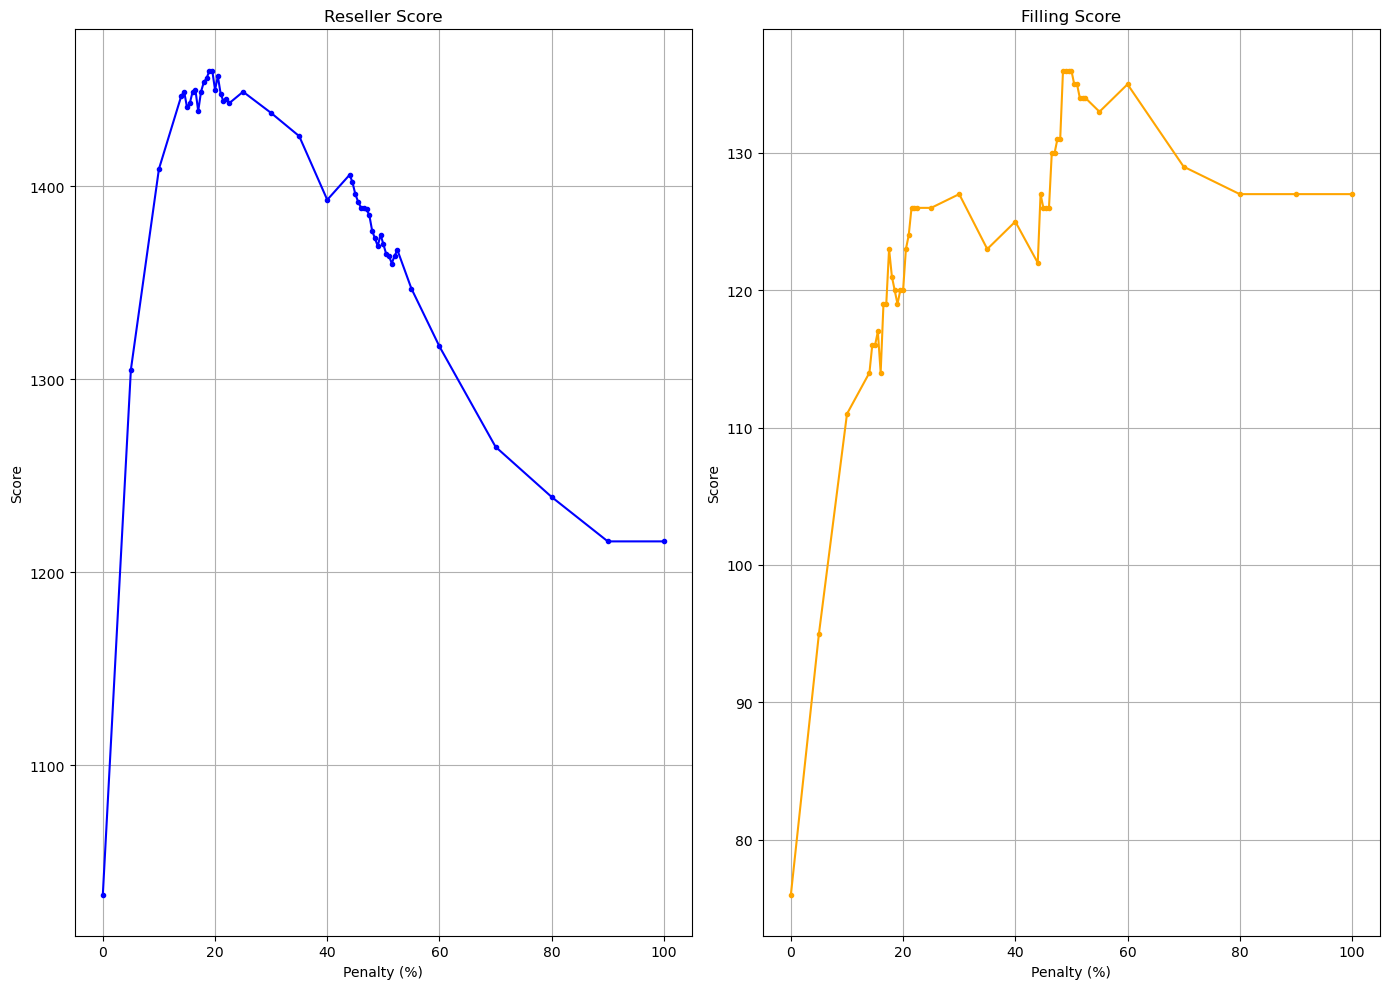

In [18]:
# ── Sensitivity Analysis Cell ───────────────────────────────────────────────
# Nigeria only, varying anti-clustering penalty from 0% to 100%
# Requires: full_chain_lpg.gpkg with layers 'resell' and 'filling'
#           (ground truth real facilities for Nigeria)

# ── helper: modified allocation with adjustable penalty ──────────────────────


# ── scoring function ─────────────────────────────────────────────────────────
def compute_score(alloc_coords, real_gdf, max_dist=5000):
    """
    score = (real facilities within max_dist of any allocated)
          - (allocated facilities with NO real facility within max_dist)
    returns score, n_real_within, n_alloc_isolated
    """
    if not alloc_coords or len(real_gdf) == 0:
        return 0, 0, 0

    alloc = np.array(alloc_coords)          # (N,2)  x,y
    real_pts = np.array(list(zip(real_gdf.geometry.x, real_gdf.geometry.y)))  # (M,2)

    tree_alloc = cKDTree(alloc)
    tree_real  = cKDTree(real_pts)

    # real facilities within max_dist of any allocated point
    dist_real_to_alloc, _ = tree_alloc.query(real_pts, k=1, distance_upper_bound=max_dist+1)
    n_real_within = np.sum(dist_real_to_alloc <= max_dist)

    # allocated points with NO real facility within max_dist
    dist_alloc_to_real, _ = tree_real.query(alloc, k=1, distance_upper_bound=max_dist+1)
    n_alloc_isolated = np.sum(dist_alloc_to_real > max_dist)

    score = n_real_within - n_alloc_isolated
    return score, n_real_within, n_alloc_isolated

# ── LOAD EVERYTHING FOR NIGERIA ─────────────────────────────────────────────
country_name = 'nigeria'
safe = 'nigeria'

# get country geometry
world = gpd.read_file(COUNTRIES_SHP).to_crs(TARGET_CRS)
name_col = None
for col in ['ADMIN', 'NAME', 'SOVEREIGNT']:
    if col in world.columns:
        name_col = col
        break
world['name_lower'] = world[name_col].str.lower()
match = world[world['name_lower'] == country_name]
if match.empty:
    raise ValueError(f"{country_name} not found in boundaries")
country_geom = match.geometry.unary_union

# paths for rasters (same as in main loop)
pop_path      = os.path.join(SHARED_INPUT_DIR, f"population_{safe}.tif")
urban_path    = os.path.join(SHARED_INPUT_DIR, f"urban_{safe}.tif")
income_path   = os.path.join(SHARED_INPUT_DIR, f"income_{safe}.tif")
friction_path = os.path.join(SHARED_INPUT_DIR, f"friction_{safe}.tif")

has_income = os.path.exists(income_path)
if not os.path.exists(pop_path) or not os.path.exists(urban_path) or not os.path.exists(friction_path):
    raise FileNotFoundError("Missing one or more mandatory rasters for Nigeria")

# reference grid from population
with rasterio.open(pop_path) as ref:
    ref_shape     = ref.shape
    ref_transform = ref.transform
    ref_crs       = ref.crs
    pop_data      = ref.read(1).astype(float)
    nd = ref.nodata
    if nd is not None:
        pop_data[pop_data == nd] = np.nan

# align other rasters
urban_data    = align_raster(urban_path,    ref_shape, ref_transform, ref_crs)
friction_data = align_raster(friction_path, ref_shape, ref_transform, ref_crs)
income_data   = align_raster(income_path,   ref_shape, ref_transform, ref_crs) if has_income else None

# compute neighbourhoods (same parameters as main loop)
CATCHMENT_RADIUS_KM = 5.0
pixel_size_m = abs(ref_transform[0])
pop_neighborhood = compute_neighborhood_sum(pop_data, CATCHMENT_RADIUS_KM, pixel_size_m)
friction_neighborhood = compute_neighborhood_mean(friction_data, CATCHMENT_RADIUS_KM, pixel_size_m)
income_neighborhood = compute_neighborhood_mean(income_data, CATCHMENT_RADIUS_KM, pixel_size_m) if has_income else None

# urban / rural masks
urban_mask   = (urban_data >= URBAN_THRESHOLD) & (~np.isnan(urban_data))
rural_mask   = (urban_data <  URBAN_THRESHOLD) & (~np.isnan(urban_data))
is_urban_bin = urban_mask.astype(np.uint8)

# LPG shares from config
c_cfg = SSA_COUNTRIES[country_name]
urban_share = c_cfg.get('urban_lpg_share')
rural_share = c_cfg.get('rural_lpg_share')
urban_pop = np.nansum(pop_data[urban_mask])
rural_pop = np.nansum(pop_data[rural_mask])
urban_lpg = urban_share * urban_pop
rural_lpg = rural_share * rural_pop

# facility rates
fp = NIG_PARAMS['facilities_per_1000_lpg_users']
res_urban_rate  = c_cfg.get('reseller_urban',  fp['reseller_urban'])
res_rural_rate  = c_cfg.get('reseller_rural',  fp['reseller_rural'])
fill_urban_rate = c_cfg.get('filling_urban',   fp['filling_urban'])
fill_rural_rate = c_cfg.get('filling_rural',   fp['filling_rural'])

target_res  = int(np.ceil(urban_lpg * res_urban_rate  / 1000 + rural_lpg * res_rural_rate  / 1000))
target_fill = int(np.ceil(urban_lpg * fill_urban_rate / 1000 + rural_lpg * fill_rural_rate / 1000))

# existing facilities from infrastructure.gpkg (used for seeding)
existing_resell  = gpd.read_file(INFRA_GPKG, layer='reseller_africa').to_crs(TARGET_CRS)
existing_filling = gpd.read_file(INFRA_GPKG, layer='filling_africa').to_crs(TARGET_CRS)
exist_res  = clip_gdf_to_country(existing_resell,  country_geom)
exist_fill = clip_gdf_to_country(existing_filling, country_geom)
n_exist_res  = len(exist_res)
n_exist_fill = len(exist_fill)

if USE_EXISTING_INFRASTRUCTURE:
    n_new_res  = max(0, target_res  - n_exist_res)
    n_new_fill = max(0, target_fill - n_exist_fill)
else:
    n_new_res  = target_res
    n_new_fill = target_fill

print(f"Nigeria targets: resellers={target_res} (new={n_new_res}), filling={target_fill} (new={n_new_fill})")

# probability rasters (identical to main loop)
valid_mask = (~np.isnan(pop_neighborhood)) & (~np.isnan(urban_data)) & (~np.isnan(friction_neighborhood))
if has_income:
    valid_mask &= ~np.isnan(income_neighborhood)

eff_weights = PREDICTOR_WEIGHTS.copy()
if not has_income:
    eff_weights['income'] = 0.0

prob_res = compute_probability_raster(
    pop_neighborhood, income_neighborhood, is_urban_bin, friction_neighborhood,
    scaler_pop, scaler_income, scaler_friction,
    model_res, eff_weights, valid_mask,
)
prob_fill = compute_probability_raster(
    pop_neighborhood, income_neighborhood, is_urban_bin, friction_neighborhood,
    scaler_pop, scaler_income, scaler_friction,
    model_fill, eff_weights, valid_mask,
)

# mask outside country polygon
geom_mask_arr = geometry_mask(
    [mapping(country_geom)], transform=ref_transform, invert=True, out_shape=ref_shape)
prob_res[~geom_mask_arr]  = np.nan
prob_fill[~geom_mask_arr] = np.nan

# rows/cols of existing facilities (seeds)
ex_res_rows,  ex_res_cols  = (points_to_rowcol(exist_res,  ref_transform, ref_shape)
                              if len(exist_res)  > 0 else (np.array([], int), np.array([], int)))
ex_fill_rows, ex_fill_cols = (points_to_rowcol(exist_fill, ref_transform, ref_shape)
                              if len(exist_fill) > 0 else (np.array([], int), np.array([], int)))

# ── GROUND TRUTH real facilities (full_chain_lpg.gpkg) ─────────────────────
# Adjust path if necessary; file must exist.
full_chain_path = os.path.join(DATA_ROOT, "nige_dataset/full_lpg_chain_nig_3857.gpkg")
if not os.path.exists(full_chain_path):
    raise FileNotFoundError(f"full_chain_lpg.gpkg not found at {full_chain_path}")

real_resell  = gpd.read_file(full_chain_path, layer='resell').to_crs(TARGET_CRS)
real_filling = gpd.read_file(full_chain_path, layer='filling').to_crs(TARGET_CRS)
real_resell  = clip_gdf_to_country(real_resell,  country_geom)
real_filling = clip_gdf_to_country(real_filling, country_geom)

# ── PENALTY VALUES ─────────────────────────────────────────────────────────

penalty_list = sorted(set(
    list(range(0, 101, 10))
    + list(range(0,61, 5))          
    + list(np.arange(14, 23, 0.5))    
    + list(np.arange(44, 53, 0.5))      
))

res_scores, fill_scores = [], []
adjacent_counts = []      # how many allocated facilities have a neighbour also occupied

for penalty in penalty_list:
    new_res = allocate_facilities(
        prob_res, n_new_res, ex_res_rows, ex_res_cols, ref_transform, penalty)
    new_fill = allocate_facilities(
        prob_fill, n_new_fill, ex_fill_rows, ex_fill_cols, ref_transform, penalty)

    # scores
    s_res, _, _ = compute_score(new_res, real_resell)
    s_fill, _, _ = compute_score(new_fill, real_filling)
    res_scores.append(s_res)
    fill_scores.append(s_fill)

    # count how many placed facilities have a neighbour (raster pixel adjacent) that is also occupied
    def count_adjacent_pairs(coords, transform, shape):
        from rasterio.transform import rowcol
        rows, cols = rowcol(transform, [c[0] for c in coords], [c[1] for c in coords])
        occ_set = set(zip(rows, cols))
        adj = 0
        for r, c in occ_set:
            for dr in [-1,0,1]:
                for dc in [-1,0,1]:
                    if dr==0 and dc==0: continue
                    if (r+dr, c+dc) in occ_set:
                        adj += 1
                        break
        return adj
    adj_res = count_adjacent_pairs(new_res, ref_transform, ref_shape)
    adjacent_counts.append(adj_res)   # only reseller for example


# Print table with adjacent count
print(f"{'Penalty':>7}  {'ResScore':>6}  {'FillScore':>6} {'AdjacentRes':>11}")
for p, r, f, a in zip(penalty_list, res_scores, fill_scores, adjacent_counts):
    print(f"{p:>4}%    {r:>6}    {f:>6}   {a:>11}")
print(f"\nRESULTS: the penalty value that maximises the reseller score is {penalty_list[res_scores.index(max(res_scores))]}% the one that maximises the filling score is {penalty_list[fill_scores.index(max(fill_scores))]}%")
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes = axes.flatten()

axes[0].plot(penalty_list, res_scores, 'b-o',marker='.')
axes[0].set_title('Reseller Score')
axes[0].set_xlabel('Penalty (%)'); axes[0].set_ylabel('Score'); axes[0].grid(True)

axes[1].plot(penalty_list, fill_scores, 'o-', color='orange', marker='.')
axes[1].set_title('Filling Score')
axes[1].set_xlabel('Penalty (%)'); axes[1].set_ylabel('Score'); axes[1].grid(True)


plt.tight_layout()
plt.show()